
# Sesión 02 — Modelos de Clasificación II
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Estudiante:** Gomez Muñoz David Pedro

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [ ]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

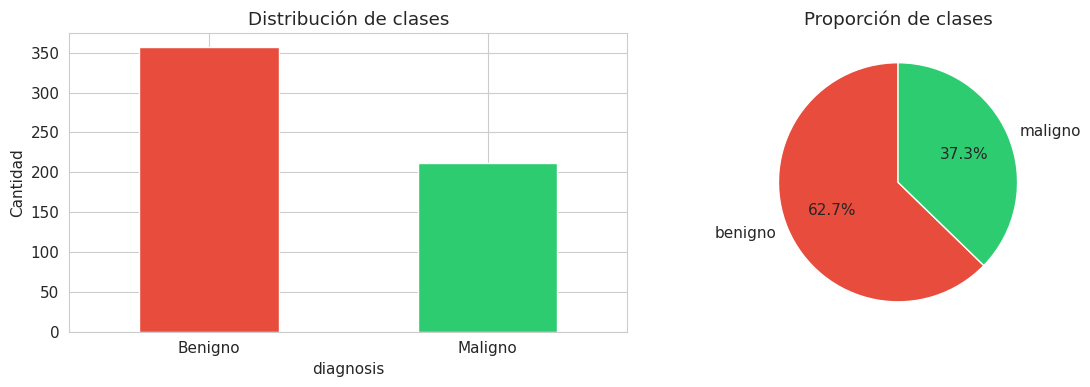

In [3]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

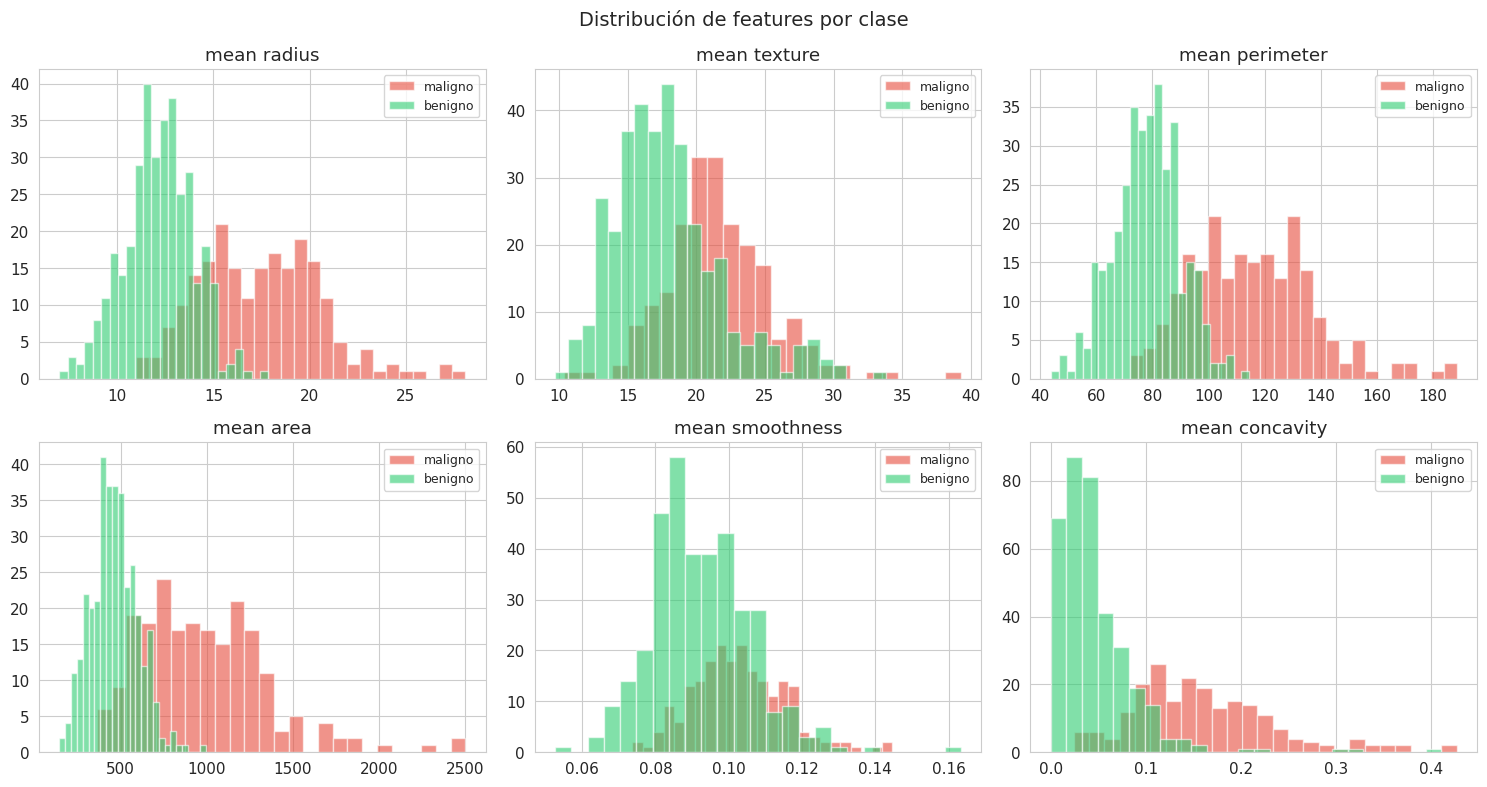

In [4]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

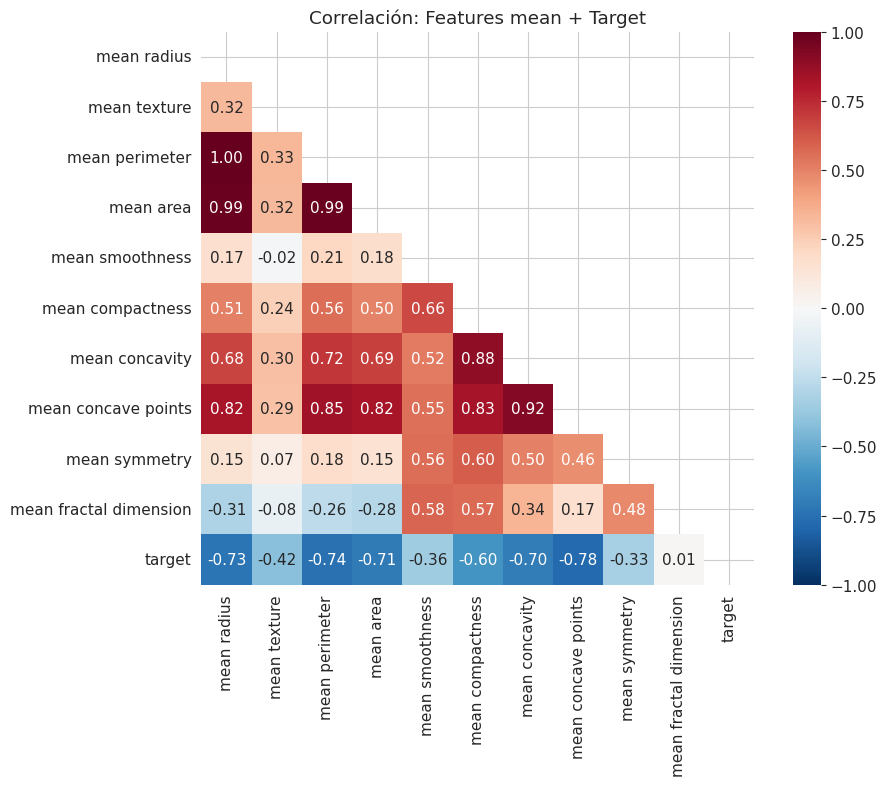

In [5]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

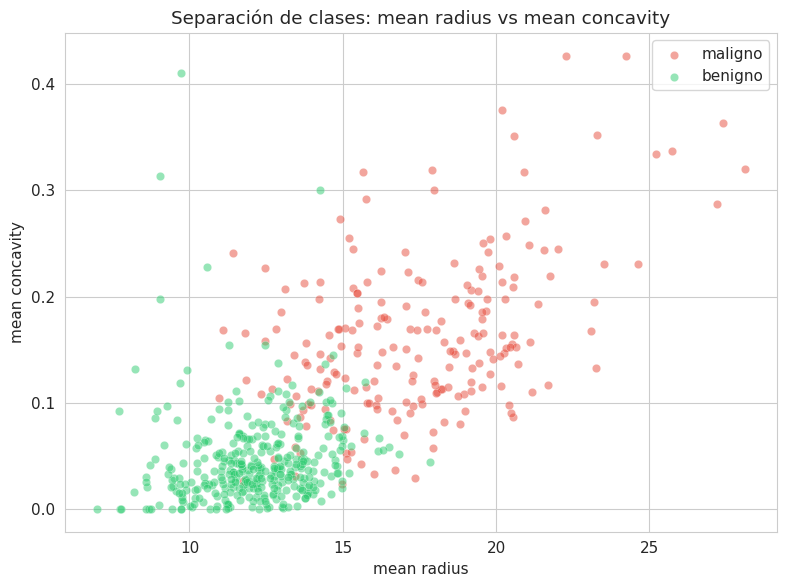

In [6]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [8]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


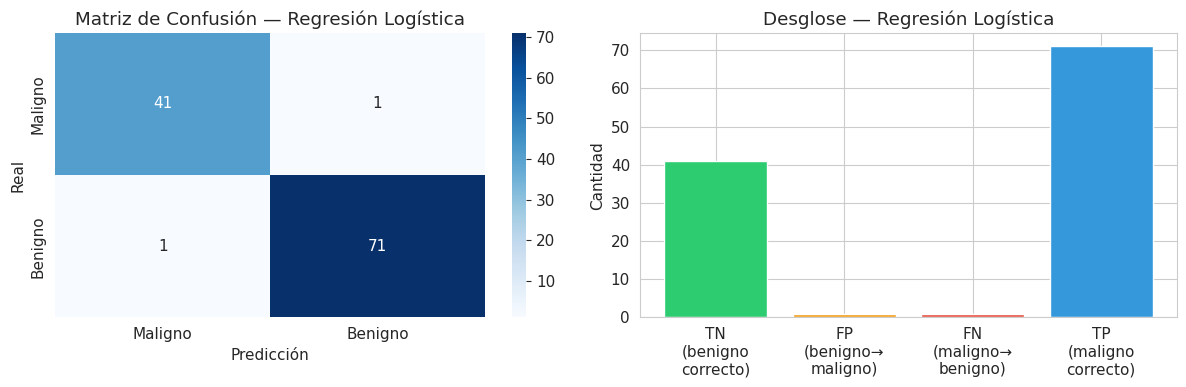


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [10]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

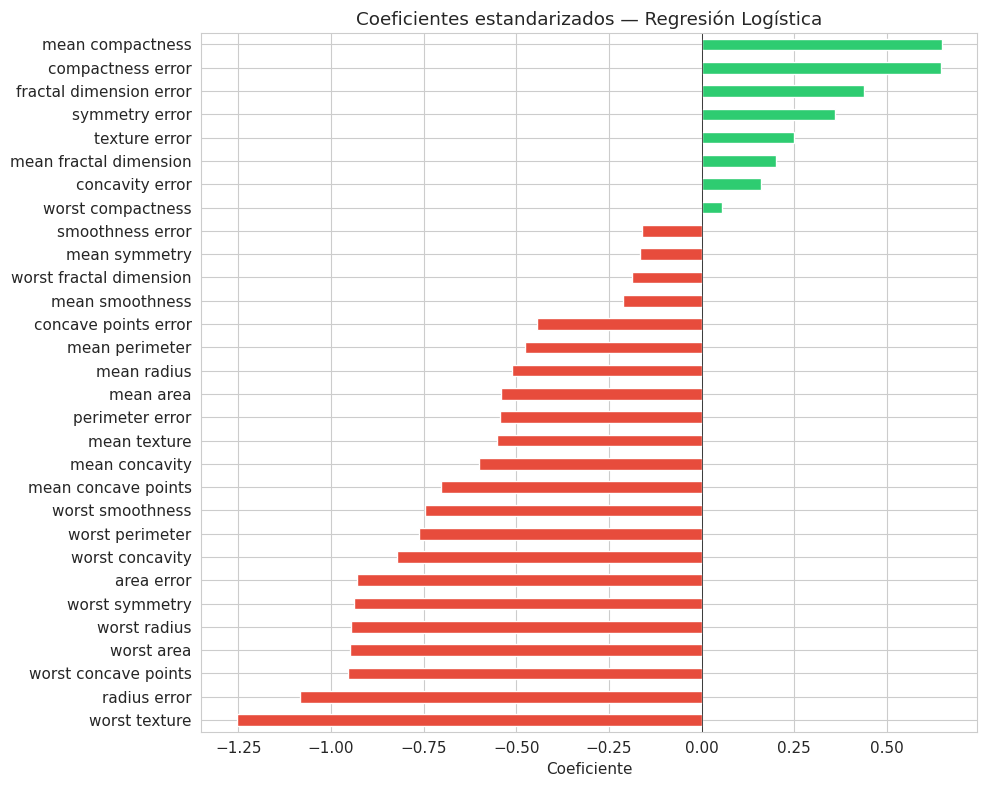

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [11]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

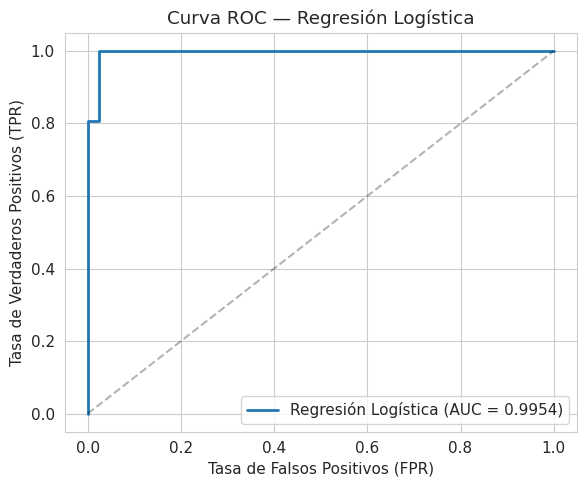

AUC: 0.9954


In [12]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [13]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [14]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


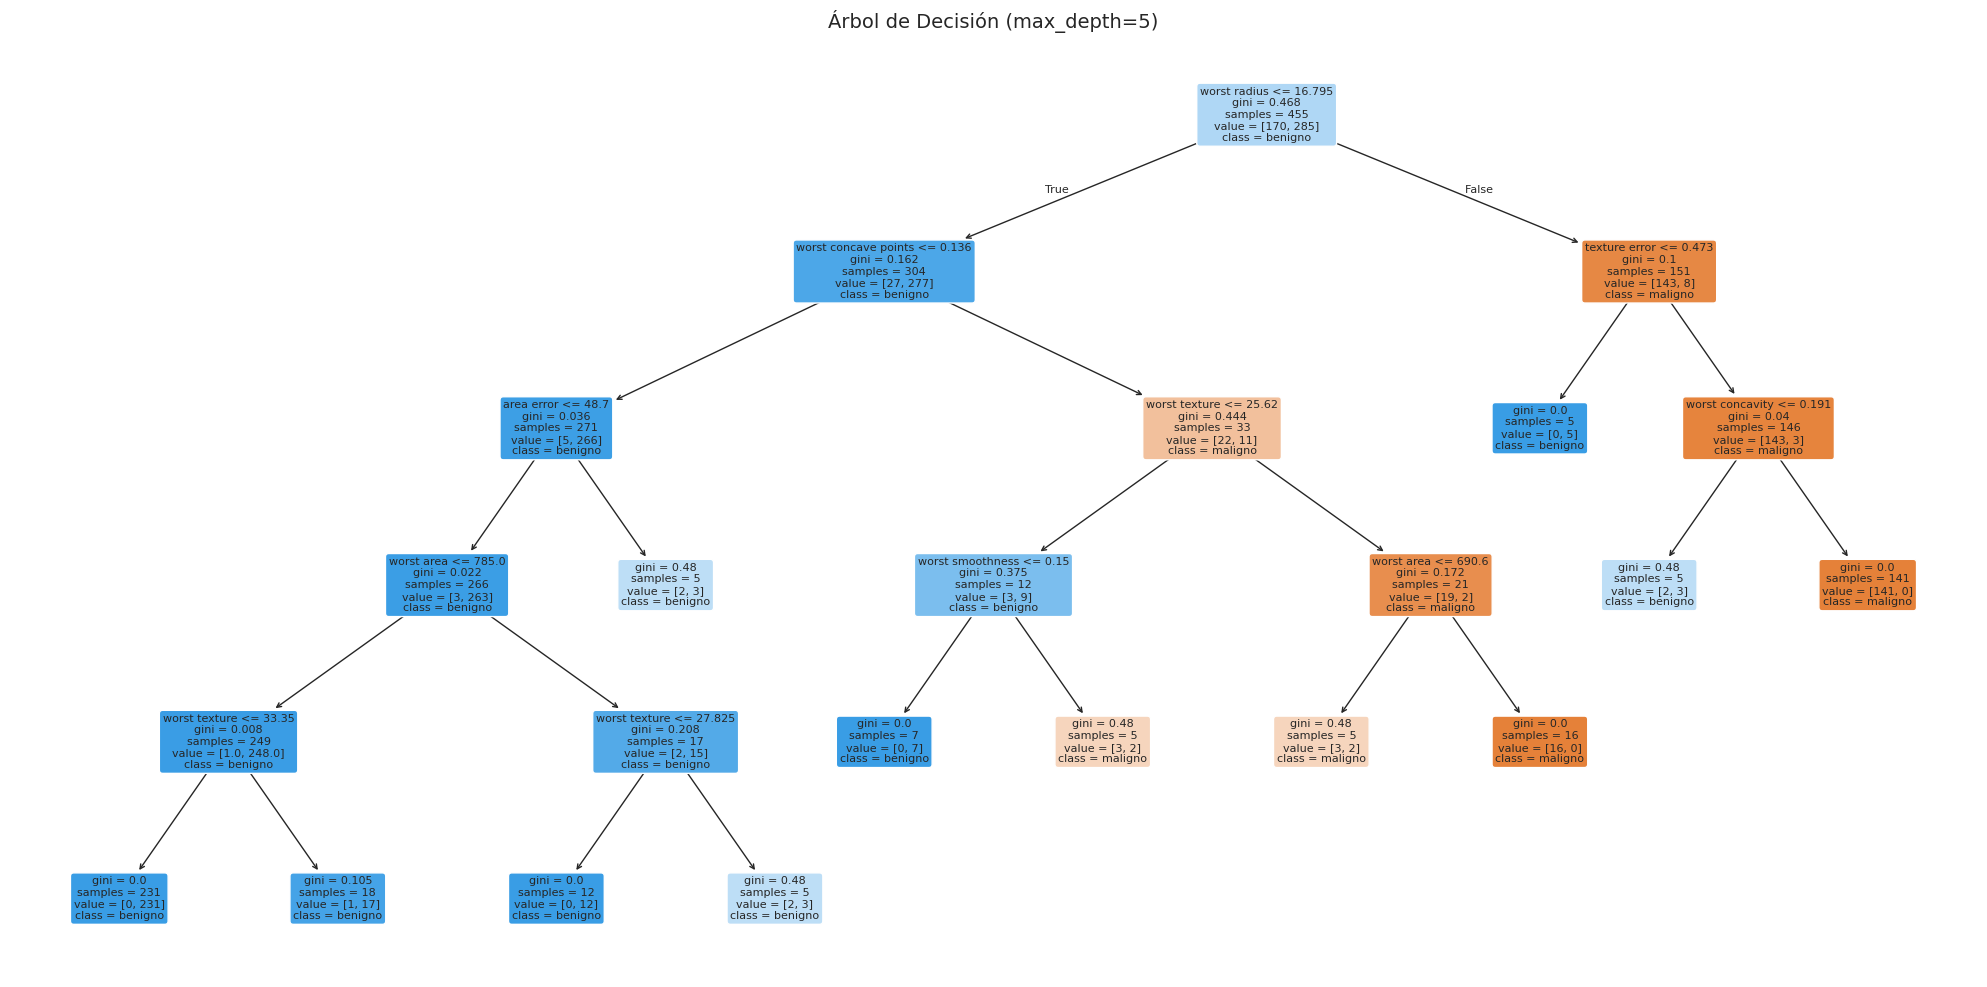

In [15]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


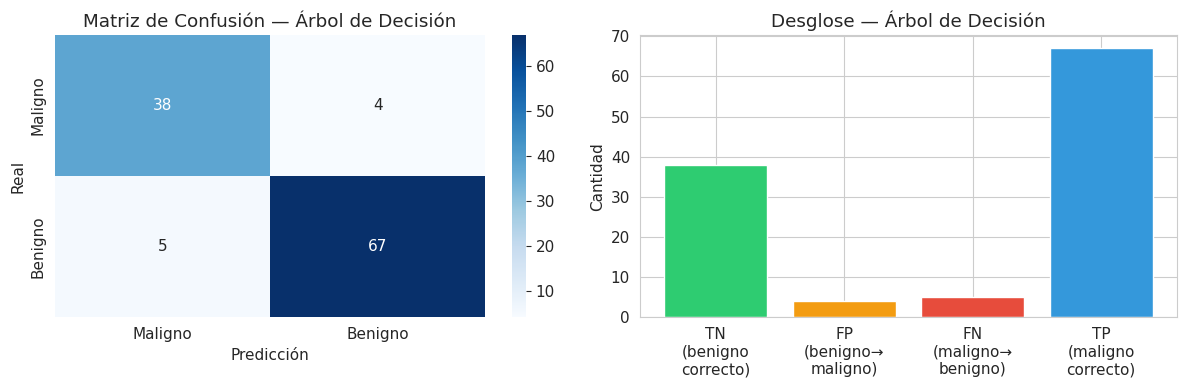


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [16]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

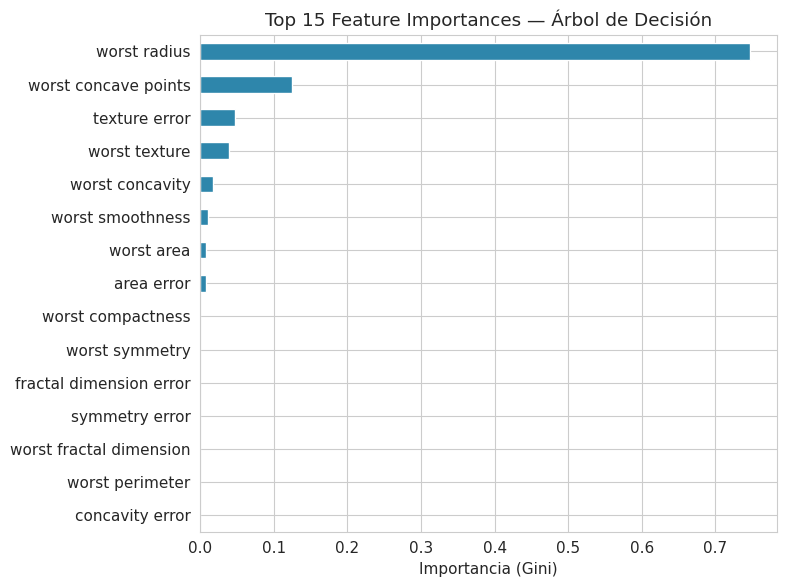

In [17]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

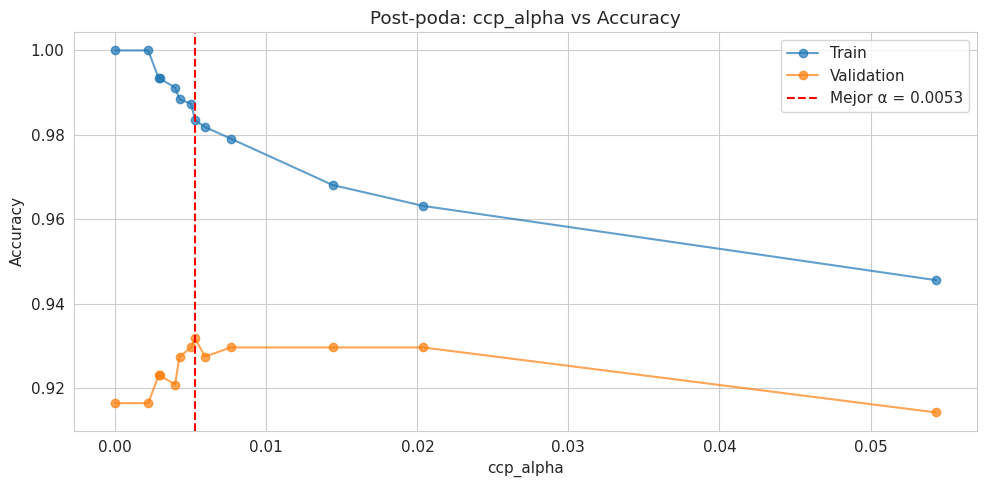

Mejor ccp_alpha: 0.005275


In [18]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [19]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


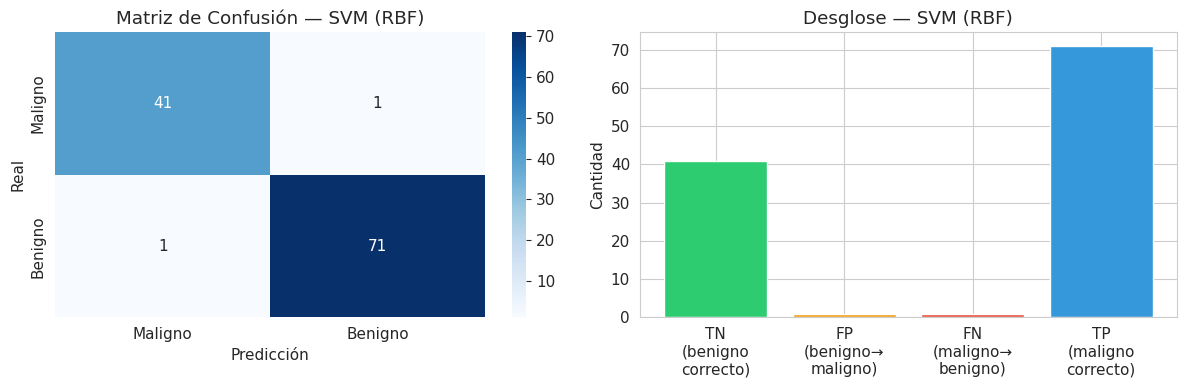


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [20]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


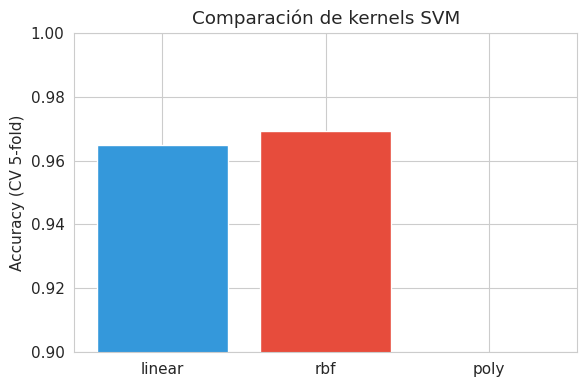

In [21]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

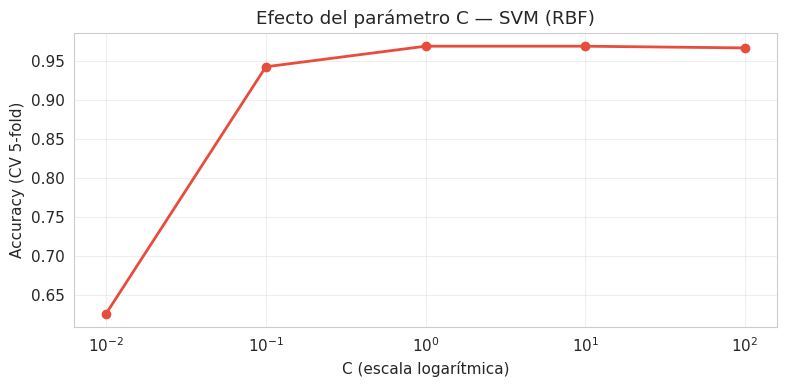


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [22]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [23]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


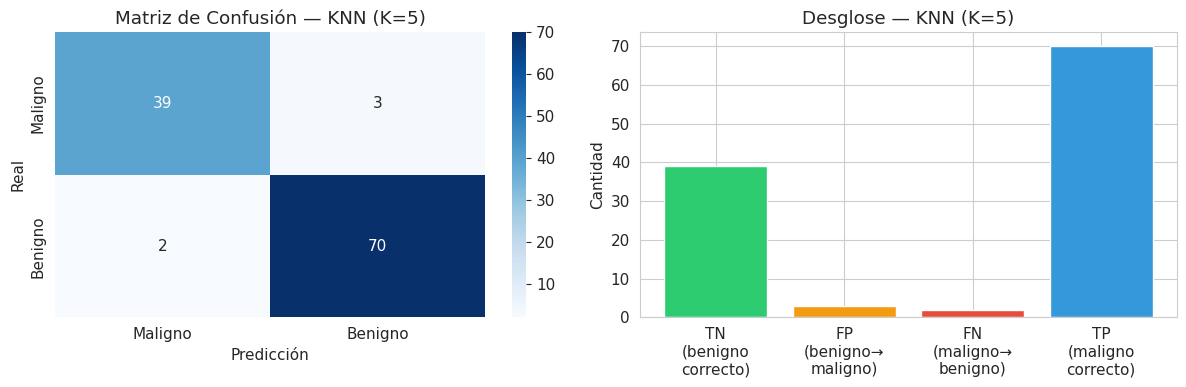


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

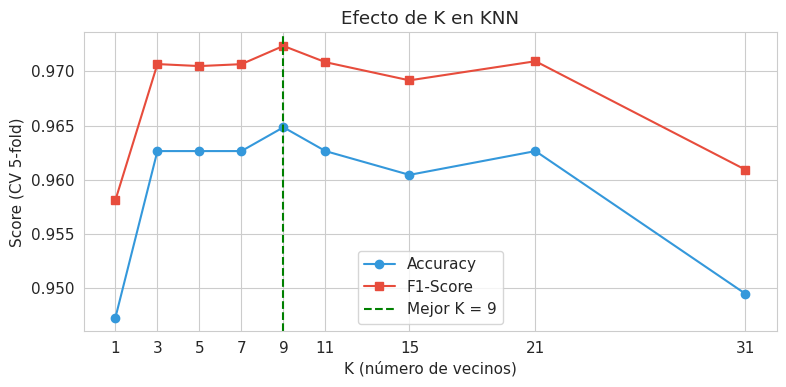

Mejor K por F1: 9
K empírico (√455): 21


In [25]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [26]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [27]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


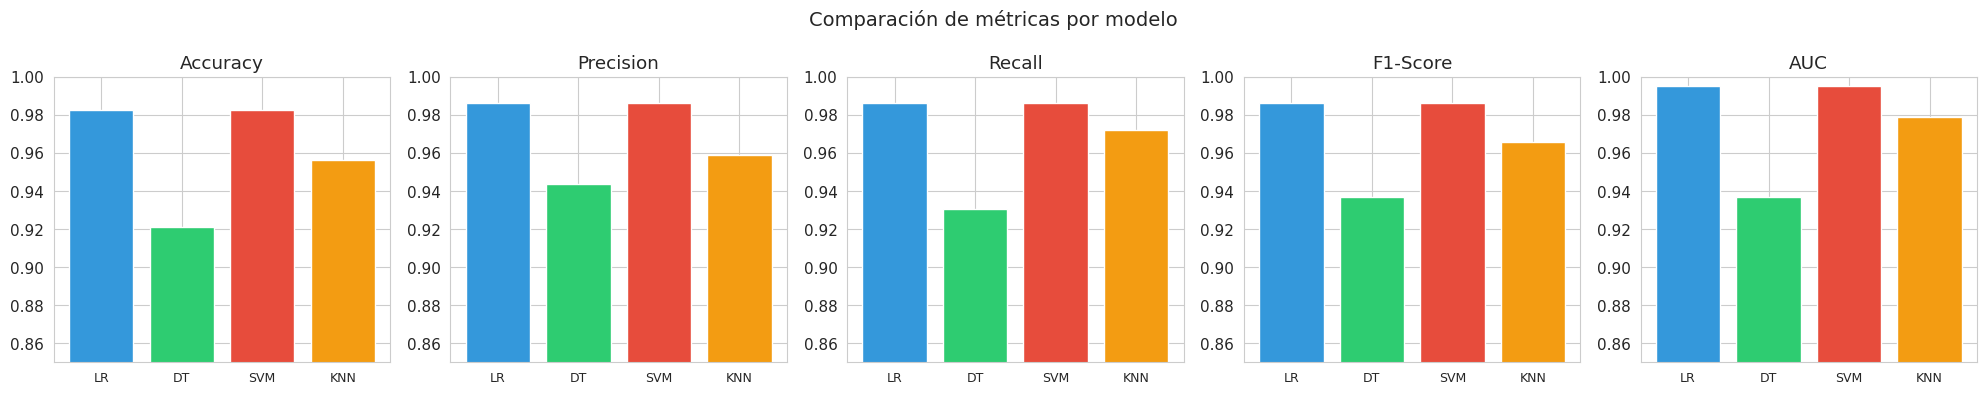

In [28]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

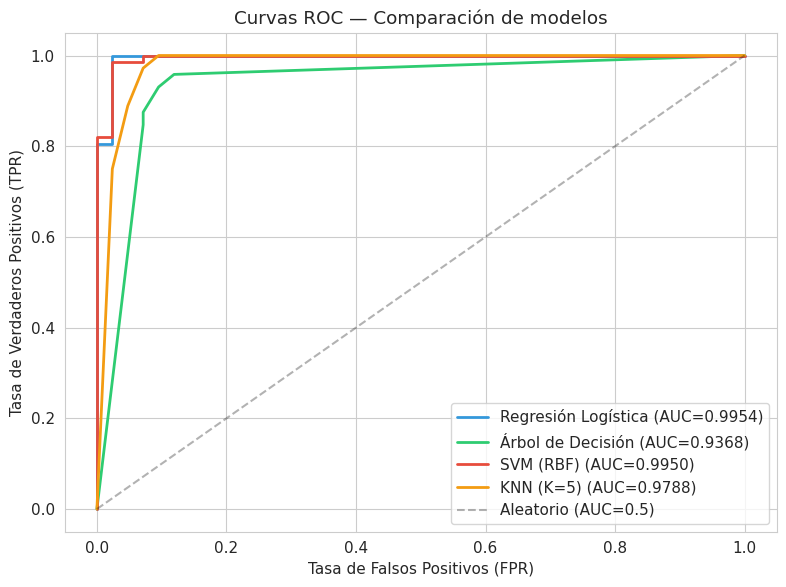

In [29]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [30]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

Optimización con GridSearchCV

In [31]:

print('OPTIMIZACIÓN CON GRIDSEARCHCV')


from sklearn.model_selection import GridSearchCV

# 1. Optimización de Regresión Logística
print('\n Buscando mejores parámetros para Regresión Logística...')
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)
print(f' Mejor LR: C = {grid_lr.best_params_["clf__C"]}, F1-Score = {grid_lr.best_score_:.4f}')

# 2. Optimización de Árbol de Decisión
print('\n Buscando mejores parámetros para Árbol de Decisión...')
param_grid_dt = {'clf__max_depth': [3, 5, 7, 10], 'clf__min_samples_leaf': [1, 5, 10]}
grid_dt = GridSearchCV(
    Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid_dt, cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print(f' Mejor DT: {grid_dt.best_params_}, F1-Score = {grid_dt.best_score_:.4f}')



OPTIMIZACIÓN CON GRIDSEARCHCV

 Buscando mejores parámetros para Regresión Logística...
 Mejor LR: C = 0.1, F1-Score = 0.9845

 Buscando mejores parámetros para Árbol de Decisión...
 Mejor DT: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}, F1-Score = 0.9500


 Manejo de Desbalance (class_weight y SMOTE)

In [32]:

print('MANEJO DE DESBALANCE (class_weight y SMOTE)')


# A) Usando class_weight='balanced'
print('\n1️ Probando con class_weight="balanced"...')
lr_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)

# Nota: en este dataset, 0 = maligno. Usamos pos_label=0 para medir el recall de la clase maligna.
recall_bal = recall_score(y_test, y_pred_bal, pos_label=0)
print(f'   → Recall (Maligno) con class_weight: {recall_bal:.4f}')

# B) Usando SMOTE (Sintetic Minority Over-sampling Technique)
print('\n2️ Probando con SMOTE...')
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f'   • Tamaño de X_train original: {X_train.shape[0]}')
    print(f'   • Tamaño de X_train con SMOTE:  {X_train_smote.shape[0]} (¡Clases balanceadas!)')

    lr_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    lr_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = lr_smote.predict(X_test)

    recall_smote = recall_score(y_test, y_pred_smote, pos_label=0)
    print(f'   → Recall (Maligno) con SMOTE: {recall_smote:.4f}')

except ImportError:
    print('   La librería "imbalanced-learn" no está instalada.')
    print('   Solución: Ejecuta esta celda: !pip install imbalanced-learn')

MANEJO DE DESBALANCE (class_weight y SMOTE)

1️ Probando con class_weight="balanced"...
   → Recall (Maligno) con class_weight: 0.9762

2️ Probando con SMOTE...
   • Tamaño de X_train original: 455
   • Tamaño de X_train con SMOTE:  570 (¡Clases balanceadas!)
   → Recall (Maligno) con SMOTE: 0.9762


---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
### Resolución del ejercicio 1: Optimización con GridSearchCV



In [33]:
# 11.1.1  Definición de pipelines y grillas de hiperparámetros
pipes_gs = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Árbol de Decisión': Pipeline([
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

grids = {
    'Regresión Logística': {'clf__C': [0.01, 0.1, 1, 10, 100]},
    'Árbol de Decisión': {'clf__max_depth': [3, 5, 7, 10, None],
                          'clf__min_samples_leaf': [1, 5, 10]},
    'SVM': {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]},
    'KNN': {'clf__n_neighbors': [3, 5, 9, 15, 21],
            'clf__weights': ['uniform', 'distance']}
}

for nombre, g in grids.items():
    n_comb = np.prod([len(v) for v in g.values()])
    print(f'{nombre}: {n_comb} combinaciones x 5 folds')


Regresión Logística: 5 combinaciones x 5 folds
Árbol de Decisión: 15 combinaciones x 5 folds
SVM: 9 combinaciones x 5 folds
KNN: 10 combinaciones x 5 folds


In [34]:
# 11.1.2  Ejecución de GridSearchCV para los 4 modelos
from sklearn.model_selection import GridSearchCV

gs_results = {}
for nombre in pipes_gs:
    gs = GridSearchCV(pipes_gs[nombre], grids[nombre],
                      cv=5, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    gs_results[nombre] = gs
    print(f'✓ {nombre} optimizado')


✓ Regresión Logística optimizado
✓ Árbol de Decisión optimizado
✓ SVM optimizado
✓ KNN optimizado


In [35]:
# 11.1.3  Mejores hiperparámetros y F1 en validación cruzada
for nombre, gs in gs_results.items():
    print(f'{nombre}')
    print(f'  Mejores parámetros: {gs.best_params_}')
    print(f'  Mejor F1 (CV 5-fold): {gs.best_score_:.4f}\n')


Regresión Logística
  Mejores parámetros: {'clf__C': 0.1}
  Mejor F1 (CV 5-fold): 0.9845

Árbol de Decisión
  Mejores parámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}
  Mejor F1 (CV 5-fold): 0.9500

SVM
  Mejores parámetros: {'clf__C': 10, 'clf__gamma': 0.01}
  Mejor F1 (CV 5-fold): 0.9844

KNN
  Mejores parámetros: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
  Mejor F1 (CV 5-fold): 0.9759



In [36]:
# 11.1.4  Evaluación en test: modelo base vs. modelo optimizado
base_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM': pipe_svm,
    'KNN': pipe_knn
}

filas = []
for nombre, gs in gs_results.items():
    y_b = base_models[nombre].predict(X_test)
    y_o = gs.best_estimator_.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'F1 base': f1_score(y_test, y_b),
        'F1 optimizado': f1_score(y_test, y_o),
        'Recall optimizado': recall_score(y_test, y_o),
        'Accuracy optimizado': accuracy_score(y_test, y_o)
    })

df_gs = pd.DataFrame(filas).set_index('Modelo')
df_gs['Mejora F1'] = df_gs['F1 optimizado'] - df_gs['F1 base']
df_gs.round(4)


,F1 base,F1 optimizado,Recall optimizado,Accuracy optimizado,Mejora F1
Modelo,,,,,
Regresión Logística,0.9861,0.9793,0.9861,0.9737,-0.0068
Árbol de Decisión,0.9371,0.9371,0.9306,0.9211,0.0000
SVM,0.9861,0.9861,0.9861,0.9825,0.0000
KNN,0.9655,0.9863,1.0000,0.9825,0.0208


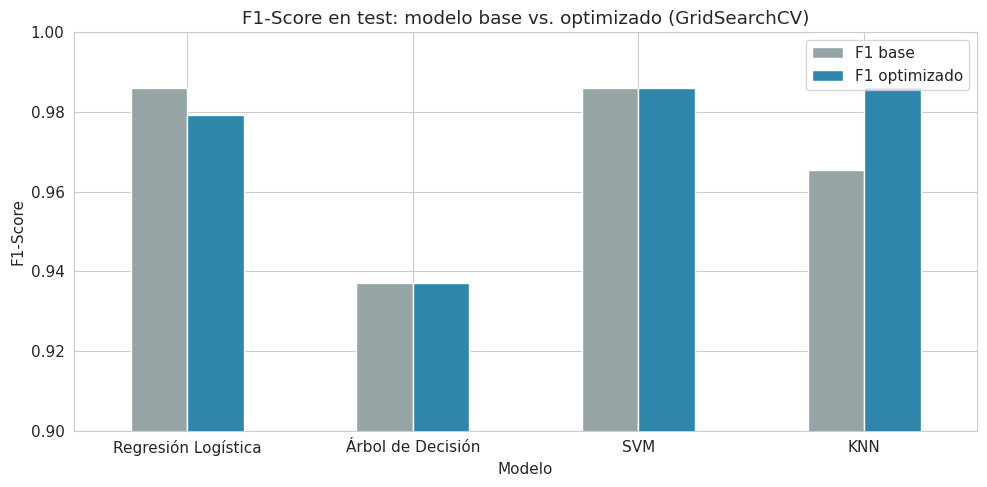

Mejor modelo optimizado: KNN (F1 test = 0.9863)


In [37]:
# 11.1.5  Comparación gráfica de los mejores modelos optimizados
ax = df_gs[['F1 base', 'F1 optimizado']].plot(kind='bar', figsize=(10, 5),
                                              color=['#95a5a6', '#2E86AB'])
ax.set_title('F1-Score en test: modelo base vs. optimizado (GridSearchCV)')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.9, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mejor = df_gs['F1 optimizado'].idxmax()
print(f'Mejor modelo optimizado: {mejor} '
      f'(F1 test = {df_gs.loc[mejor, "F1 optimizado"]:.4f})')


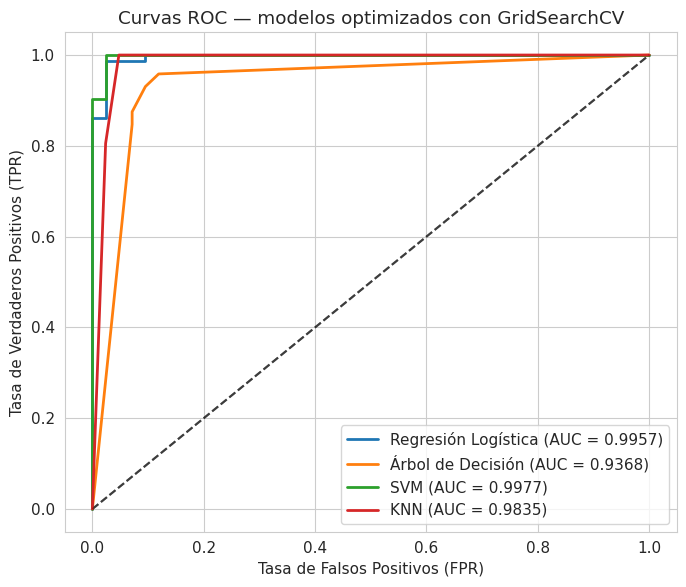

In [38]:
# 11.1.6  Curvas ROC de los 4 modelos optimizados
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, gs in gs_results.items():
    plot_roc(gs.best_estimator_, X_test, y_test, nombre, ax)
ax.set_title('Curvas ROC — modelos optimizados con GridSearchCV')
plt.tight_layout()
plt.show()


###Comparación de los mejores modelos optimizados

Se aplicó `GridSearchCV(cv=5, scoring='f1')` a los cuatro modelos. Los mejores hiperparámetros y el desempeño en test fueron:

| Modelo | Mejores hiperparámetros | F1 (CV) | F1 test base | F1 test optimizado | Recall test | Accuracy test |
|---|---|---|---|---|---|---|
| Regresión Logística | C = 0.1 | 0.9845 | 0.9861 | 0.9793 | 0.9861 | 0.9737 |
| Árbol de Decisión | max_depth = 5, min_samples_leaf = 5 | 0.9500 | 0.9371 | 0.9371 | 0.9306 | 0.9211 |
| SVM | C = 10, gamma = 0.01 | 0.9844 | 0.9861 | 0.9861 | 0.9861 | 0.9825 |
| KNN | n_neighbors = 3, weights = 'uniform' | 0.9759 | 0.9655 | 0.9863 | 1.0000 | 0.9825 |

 En validación cruzada, la Regresión Logística (0.9845) y el SVM (0.9844) obtuvieron el mejor F1, seguidos por KNN (0.9759) y el Árbol de Decisión (0.9500). En test, KNN optimizado obtuvo el F1 más alto (0.9863) y un Recall de 1.0, con una mejora de 0.0208 respecto a su versión base. El SVM optimizado quedó casi igual (0.9861) y con la misma Accuracy que KNN (0.9825). La Regresión Logística optimizada bajó levemente en test (0.9861 → 0.9793) y el Árbol de Decisión no cambió (0.9371), siendo el de menor desempeño. Las diferencias entre KNN, SVM y Regresión Logística son de menos de un punto de F1, por lo que su rendimiento es prácticamente equivalente.

---
### Resolución del ejercicio 2: Manejo de desbalance con class_weight y SMOTE



In [39]:
# 11.2.1  Sin balanceo vs. class_weight='balanced'
def crear_modelos(balanced=False):
    cw = 'balanced' if balanced else None
    return {
        'Regresión Logística': Pipeline([('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, class_weight=cw, random_state=42))]),
        'Árbol de Decisión': Pipeline([
            ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                           min_samples_leaf=5, class_weight=cw,
                                           random_state=42))]),
        'SVM': Pipeline([('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', class_weight=cw, random_state=42))]),
        'KNN': Pipeline([('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=5))])   # sin class_weight
    }

def recall_maligno(modelo):
    return recall_score(y_test, modelo.predict(X_test), pos_label=0)

modelos_sin = crear_modelos(balanced=False)
modelos_bal = crear_modelos(balanced=True)

res_cw = {}
for nombre in modelos_sin:
    modelos_sin[nombre].fit(X_train, y_train)
    modelos_bal[nombre].fit(X_train, y_train)
    res_cw[nombre] = {'Sin balanceo': recall_maligno(modelos_sin[nombre]),
                      'class_weight=balanced': recall_maligno(modelos_bal[nombre])}

pd.DataFrame(res_cw).T.round(4)


,Sin balanceo,class_weight=balanced
Regresión Logística,0.9762,0.9762
Árbol de Decisión,0.9048,0.9048
SVM,0.9762,0.9762
KNN,0.9286,0.9286


In [40]:
# 11.2.2  Aplicación de SMOTE (solo sobre el conjunto de entrenamiento)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print('Distribución de clases en entrenamiento:')
print(f'  Antes de SMOTE:   {dict(y_train.value_counts().sort_index())}')
print(f'  Después de SMOTE: {dict(pd.Series(y_res).value_counts().sort_index())}')


Distribución de clases en entrenamiento:
  Antes de SMOTE:   {0: np.int64(170), 1: np.int64(285)}
  Después de SMOTE: {0: np.int64(285), 1: np.int64(285)}


In [41]:
# 11.2.3  Entrenamiento con datos remuestreados (SMOTE) y evaluación en test original
modelos_smote = crear_modelos(balanced=False)
for nombre, modelo in modelos_smote.items():
    modelo.fit(X_res, y_res)
    res_cw[nombre]['SMOTE'] = recall_maligno(modelo)

df_recall = pd.DataFrame(res_cw).T
df_recall.round(4)


,Sin balanceo,class_weight=balanced,SMOTE
Regresión Logística,0.9762,0.9762,0.9762
Árbol de Decisión,0.9048,0.9048,0.9286
SVM,0.9762,0.9762,0.9762
KNN,0.9286,0.9286,0.9524


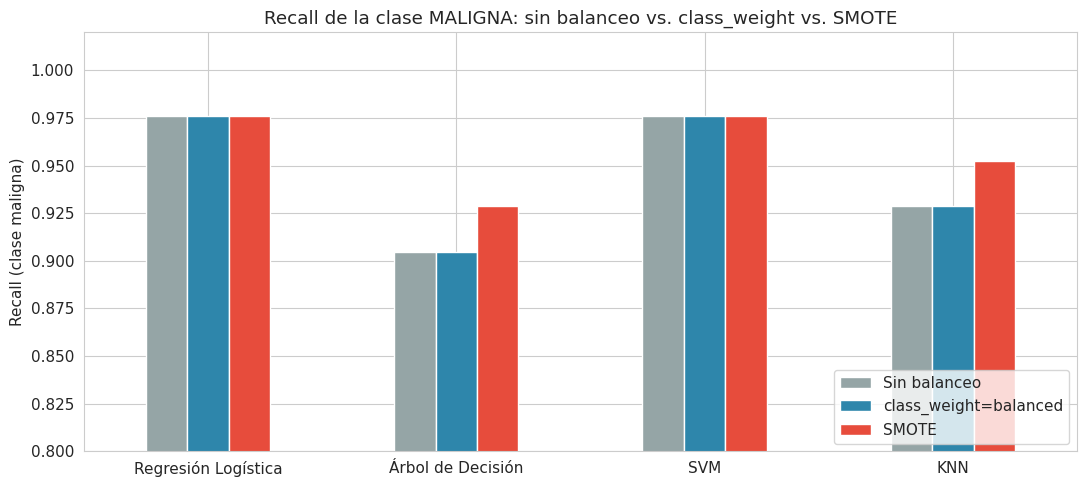

In [42]:
# 11.2.4  Comparación gráfica del Recall de la clase maligna
ax = df_recall.plot(kind='bar', figsize=(11, 5),
                    color=['#95a5a6', '#2E86AB', '#e74c3c'])
ax.set_title('Recall de la clase MALIGNA: sin balanceo vs. class_weight vs. SMOTE')
ax.set_ylabel('Recall (clase maligna)')
ax.set_ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [43]:
# 11.2.5  Falsos negativos (malignos no detectados) por escenario
def falsos_negativos(modelo):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    return cm[0, 1]   # real maligno (0) predicho benigno (1)

fn = {nombre: {'Sin balanceo': falsos_negativos(modelos_sin[nombre]),
               'class_weight=balanced': falsos_negativos(modelos_bal[nombre]),
               'SMOTE': falsos_negativos(modelos_smote[nombre])}
      for nombre in modelos_sin}
print('Falsos negativos (maligno clasificado como benigno) sobre', (y_test == 0).sum(), 'malignos en test:')
pd.DataFrame(fn).T


Falsos negativos (maligno clasificado como benigno) sobre 42 malignos en test:


,Sin balanceo,class_weight=balanced,SMOTE
Regresión Logística,1,1,1
Árbol de Decisión,4,4,3
SVM,1,1,1
KNN,3,3,2


### Recall de la clase maligna con y sin balanceo

Recall de la clase maligna (`pos_label=0`) sobre 42 casos malignos en test:

| Modelo | Sin balanceo | class_weight='balanced' | SMOTE |
|---|---|---|---|
| Regresión Logística | 0.9762 | 0.9762 | 0.9762 |
| Árbol de Decisión | 0.9048 | 0.9048 | 0.9286 |
| SVM | 0.9762 | 0.9762 | 0.9762 |
| KNN | 0.9286 | 0.9286* | 0.9524 |

KNN no tiene el parámetro `class_weight`, por lo que su resultado es el mismo que sin balanceo.

Malignos no detectados (falsos negativos): Regresión Logística 1, 1 y 1; Árbol de Decisión 4, 4 y 3; SVM 1, 1 y 1; KNN 3, 3 y 2 (sin balanceo, `class_weight` y SMOTE, respectivamente).

 Con `class_weight='balanced'` el Recall de la clase maligna no cambió en ningún modelo respecto a no balancear. Con SMOTE, el Recall subió en el Árbol de Decisión (0.9048 → 0.9286) y en KNN (0.9286 → 0.9524), y se mantuvo igual en la Regresión Logística y el SVM (0.9762). En este dataset el balanceo solo benefició a los modelos que más casos malignos dejaban sin detectar.


---
### Resolución del ejercicio 3: Dataset propio

Usamos el dataset **Pima Indians Diabetes** (UCI / OpenML `dataset_37_diabetes`), donde se predice si una paciente presenta diabetes (`tested_positive`) a partir de 8 variables clínicas.


In [ ]:
# 11.3.1  Carga del dataset (ARFF)
from scipy.io import arff
from sklearn.impute import SimpleImputer

# Descarga automática del dataset desde el repositorio de GitHub (si no está ya en el entorno)
import os, urllib.request

ruta = 'diabetes_dataset_limpio.arff'
if not os.path.exists(ruta):
    url = ('https://raw.githubusercontent.com/davimunoz345-ux/Ingenier-a-de-Conocimientos/main/'
           'diabetes_dataset_limpio_ejercicio%203_modelos%20de%20clasificaci%C3%B3n%20II.arff')
    urllib.request.urlretrieve(url, ruta)
    print('Dataset descargado desde GitHub')
datos, meta = arff.loadarff(ruta)
df_d = pd.DataFrame(datos)
df_d['class'] = df_d['class'].str.decode('utf-8')
df_d['target'] = (df_d['class'] == 'tested_positive').astype(int)

feats_d = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

print(f'Dataset: {df_d.shape[0]} registros, {len(feats_d)} features')
print(f'\nValores faltantes por variable:')
print(df_d[feats_d].isnull().sum())
print(f'\nDistribución de clases:')
print(df_d['class'].value_counts())
df_d.head()


Dataset: 768 registros, 8 features

Valores faltantes por variable:
preg      0
plas      5
pres     35
skin    227
insu    374
mass     11
pedi      0
age       0
dtype: int64

Distribución de clases:
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


,preg,plas,pres,skin,insu,mass,pedi,age,class,target
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,tested_positive,1
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,tested_negative,0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,tested_positive,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,tested_negative,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,tested_positive,1


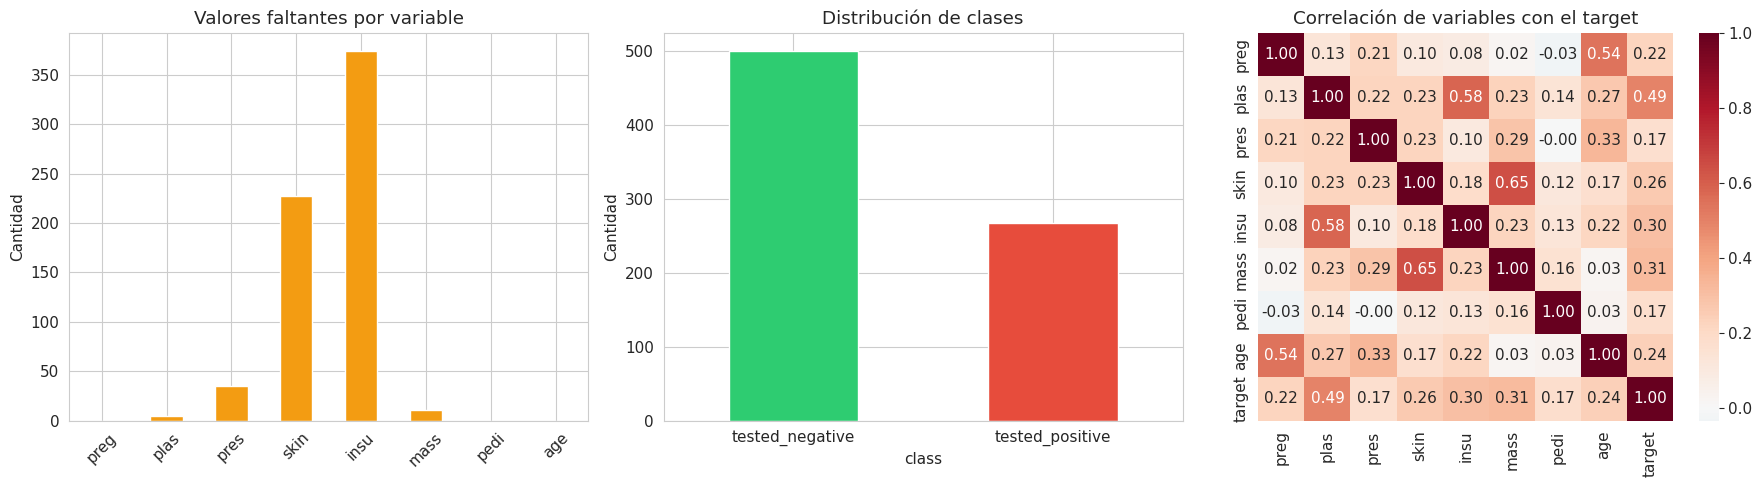

In [ ]:
# 11.3.2  Exploración: valores faltantes, distribución de clases y correlaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_d[feats_d].isnull().sum().plot(kind='bar', ax=axes[0], color='#f39c12')
axes[0].set_title('Valores faltantes por variable')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

df_d['class'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribución de clases')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)

sns.heatmap(df_d[feats_d + ['target']].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[2])
axes[2].set_title('Correlación de variables con el target')

plt.tight_layout()
plt.show()


In [ ]:
# 11.3.3  Split estratificado 80/20 y validación cruzada
Xd = df_d[feats_d].copy()
yd = df_d['target'].copy()

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.2, random_state=42, stratify=yd
)
skf_d = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Entrenamiento: {Xd_train.shape[0]} muestras | Test: {Xd_test.shape[0]} muestras')
print(f'Proporción de diabetes en train: {yd_train.mean():.1%} | en test: {yd_test.mean():.1%}')


Entrenamiento: 614 muestras | Test: 154 muestras
Proporción de diabetes en train: 34.9% | en test: 35.1%


In [ ]:
# 11.3.4  Definición de los 6 modelos (4 de la sesión + 2 adicionales)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def imp():
    return ('imputer', SimpleImputer(strategy='median'))

modelos_d = {
    'Regresión Logística': Pipeline([imp(), ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Árbol de Decisión': Pipeline([imp(),
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                       min_samples_leaf=5, random_state=42))]),
    'SVM': Pipeline([imp(), ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'KNN': Pipeline([imp(), ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=9))]),
    'Random Forest': Pipeline([imp(),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=6,
                                       random_state=42))]),
    'Gradient Boosting': Pipeline([imp(),
        ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                           learning_rate=0.1, random_state=42))])
}
print('Modelos a evaluar:', list(modelos_d.keys()))


Modelos a evaluar: ['Regresión Logística', 'Árbol de Decisión', 'SVM', 'KNN', 'Random Forest', 'Gradient Boosting']


In [ ]:
# 11.3.5  Validación cruzada estratificada (5-fold) en entrenamiento
cv_d = {}
for nombre, modelo in modelos_d.items():
    cv = cross_validate(modelo, Xd_train, yd_train, cv=skf_d,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                        return_train_score=True)
    cv_d[nombre] = {
        'Acc CV': cv['test_accuracy'].mean(),
        'F1 CV': cv['test_f1'].mean(),
        'F1 CV (std)': cv['test_f1'].std(),
        'AUC CV': cv['test_roc_auc'].mean(),
        'Acc train': cv['train_accuracy'].mean()
    }

df_cv_d = pd.DataFrame(cv_d).T
df_cv_d['Brecha (train-CV)'] = df_cv_d['Acc train'] - df_cv_d['Acc CV']
df_cv_d.round(4)


,Acc CV,F1 CV,F1 CV (std),AUC CV,Acc train,Brecha (train-CV)
Regresión Logística,0.7882,0.6545,0.0244,0.8434,0.7936,0.0053
Árbol de Decisión,0.7230,0.5684,0.0742,0.7657,0.8253,0.1023
SVM,0.7801,0.6485,0.0187,0.8333,0.8375,0.0574
KNN,0.7557,0.6248,0.0379,0.8147,0.8127,0.0570
Random Forest,0.7752,0.6433,0.0160,0.8330,0.9007,0.1254
Gradient Boosting,0.7557,0.6189,0.0347,0.8209,0.8815,0.1258


In [ ]:
# 11.3.6  Entrenamiento final y métricas en test
metricas_d = {}
for nombre, modelo in modelos_d.items():
    modelo.fit(Xd_train, yd_train)
    y_pred = modelo.predict(Xd_test)
    y_prob = modelo.predict_proba(Xd_test)[:, 1]
    metricas_d[nombre] = {
        'Accuracy': accuracy_score(yd_test, y_pred),
        'Precision': precision_score(yd_test, y_pred, zero_division=0),
        'Recall': recall_score(yd_test, y_pred),
        'F1-Score': f1_score(yd_test, y_pred),
        'AUC': auc(*roc_curve(yd_test, y_prob)[:2])
    }

df_met_d = pd.DataFrame(metricas_d).T
df_met_d.round(4)


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.7078,0.6000,0.5000,0.5455,0.8130
Árbol de Decisión,0.7727,0.6508,0.7593,0.7009,0.7992
SVM,0.7403,0.6522,0.5556,0.6000,0.7964
KNN,0.7403,0.6346,0.6111,0.6226,0.7951
Random Forest,0.7338,0.6512,0.5185,0.5773,0.8083
Gradient Boosting,0.7403,0.6522,0.5556,0.6000,0.8231


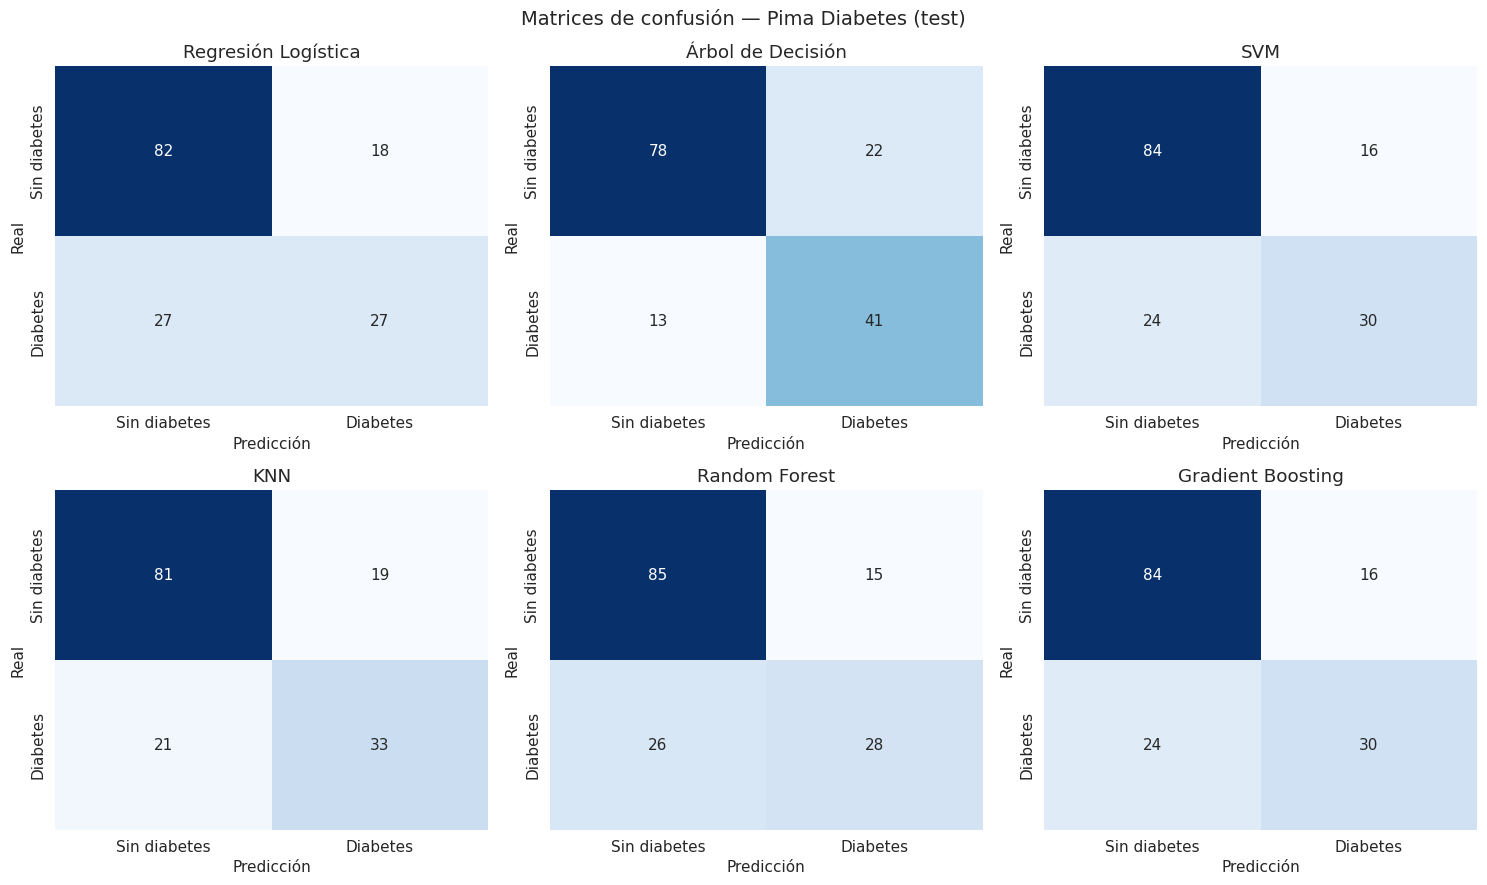

In [ ]:
# 11.3.7  Matrices de confusión de los 6 modelos
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (nombre, modelo) in zip(axes.ravel(), modelos_d.items()):
    cm = confusion_matrix(yd_test, modelo.predict(Xd_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Sin diabetes', 'Diabetes'],
                yticklabels=['Sin diabetes', 'Diabetes'])
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión — Pima Diabetes (test)', fontsize=14)
plt.tight_layout()
plt.show()


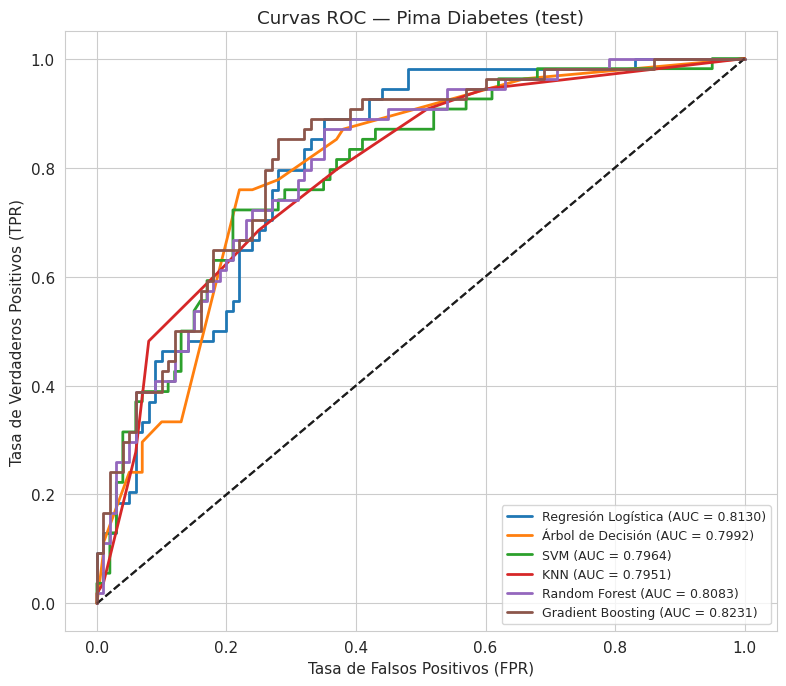

In [ ]:
# 11.3.8  Curvas ROC de los 6 modelos
fig, ax = plt.subplots(figsize=(8, 7))
for nombre, modelo in modelos_d.items():
    plot_roc(modelo, Xd_test, yd_test, nombre, ax)
ax.set_title('Curvas ROC — Pima Diabetes (test)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# 11.3.9  Matriz de selección de modelos (puntaje ponderado)
# Criterios: rendimiento (F1 CV), capacidad discriminativa (AUC),
# sensibilidad (Recall, clave en diagnóstico), estabilidad (std F1 CV) y bajo sobreajuste
criterios = pd.DataFrame({
    'F1 CV':        df_cv_d['F1 CV'],
    'AUC test':     df_met_d['AUC'],
    'Recall test':  df_met_d['Recall'],
    'Estabilidad':  -df_cv_d['F1 CV (std)'],
    'Bajo sobreajuste': -df_cv_d['Brecha (train-CV)']
})
pesos = {'F1 CV': 0.30, 'AUC test': 0.25, 'Recall test': 0.20,
         'Estabilidad': 0.10, 'Bajo sobreajuste': 0.15}

# Normalización min-max a escala 0-10 (10 = mejor modelo en ese criterio)
norm = (criterios - criterios.min()) / (criterios.max() - criterios.min()) * 10
matriz = norm.copy()
matriz['PUNTAJE PONDERADO'] = sum(norm[c] * w for c, w in pesos.items())
matriz = matriz.sort_values('PUNTAJE PONDERADO', ascending=False)

print('Pesos:', pesos)
matriz.round(2)


Pesos: {'F1 CV': 0.3, 'AUC test': 0.25, 'Recall test': 0.2, 'Estabilidad': 0.1, 'Bajo sobreajuste': 0.15}


,F1 CV,AUC test,Recall test,Estabilidad,Bajo sobreajuste,PUNTAJE PONDERADO
Regresión Logística,10.00,6.37,0.00,8.55,10.00,6.95
Gradient Boosting,5.86,10.00,2.14,6.79,0.00,5.37
SVM,9.29,0.46,2.14,9.53,5.68,5.14
Random Forest,8.69,4.72,0.71,10.00,0.03,4.93
KNN,6.55,0.00,4.29,6.23,5.71,4.30
Árbol de Decisión,0.00,1.45,10.00,0.00,1.95,2.66


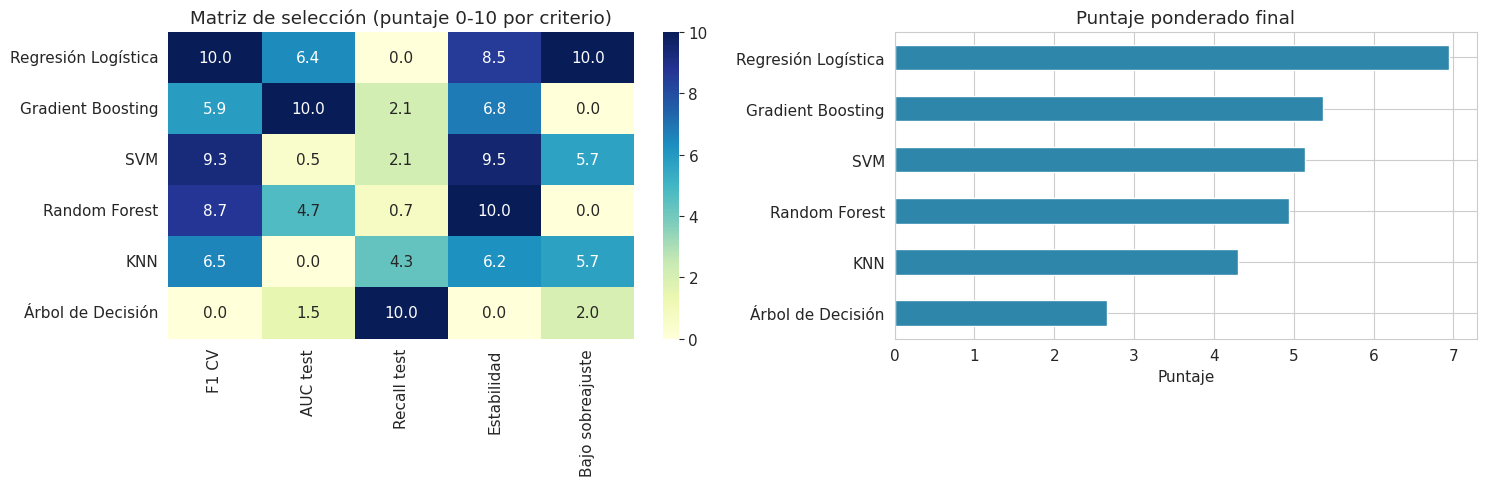

In [ ]:
# 11.3.10  Visualización de la matriz de selección
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(matriz.drop(columns='PUNTAJE PONDERADO'), annot=True, fmt='.1f',
            cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Matriz de selección (puntaje 0-10 por criterio)')

matriz['PUNTAJE PONDERADO'].sort_values().plot(kind='barh', ax=axes[1], color='#2E86AB')
axes[1].set_title('Puntaje ponderado final')
axes[1].set_xlabel('Puntaje')

plt.tight_layout()
plt.show()


In [ ]:
# 11.3.11  Modelo seleccionado y evaluación final
mejor_d = matriz['PUNTAJE PONDERADO'].idxmax()
print(f'MODELO SELECCIONADO: {mejor_d}')
print(f'  Puntaje ponderado: {matriz.loc[mejor_d, "PUNTAJE PONDERADO"]:.2f} / 10\n')

y_pred_mejor = modelos_d[mejor_d].predict(Xd_test)
print(classification_report(yd_test, y_pred_mejor,
                            target_names=['sin diabetes', 'diabetes']))


MODELO SELECCIONADO: Regresión Logística
  Puntaje ponderado: 6.95 / 10

              precision    recall  f1-score   support

sin diabetes       0.75      0.82      0.78       100
    diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### DOCUMENTACIÓN DE RESULTADOS

#### Métricas

Métricas en el conjunto de test (154 muestras):

| Modelo | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.7078 | 0.6000 | 0.5000 | 0.5455 | 0.8130 |
| Árbol de Decisión | 0.7727 | 0.6508 | 0.7593 | 0.7009 | 0.7992 |
| SVM | 0.7403 | 0.6522 | 0.5556 | 0.6000 | 0.7964 |
| KNN | 0.7403 | 0.6346 | 0.6111 | 0.6226 | 0.7951 |
| Random Forest | 0.7338 | 0.6512 | 0.5185 | 0.5773 | 0.8083 |
| Gradient Boosting | 0.7403 | 0.6522 | 0.5556 | 0.6000 | 0.8231 |

Métricas en validación cruzada (5-fold) sobre el conjunto de entrenamiento:

| Modelo | Accuracy CV | F1 CV | Std F1 CV | AUC CV | Brecha train-CV |
|---|---|---|---|---|---|
| Regresión Logística | 0.7882 | 0.6545 | 0.0244 | 0.8434 | 0.0053 |
| Árbol de Decisión | 0.7230 | 0.5684 | 0.0742 | 0.7657 | 0.1023 |
| SVM | 0.7801 | 0.6485 | 0.0187 | 0.8333 | 0.0574 |
| KNN | 0.7557 | 0.6248 | 0.0379 | 0.8147 | 0.0570 |
| Random Forest | 0.7752 | 0.6433 | 0.0160 | 0.8330 | 0.1254 |
| Gradient Boosting | 0.7557 | 0.6189 | 0.0347 | 0.8209 | 0.1258 |

#### Curvas ROC

Ordenados por AUC en test: Gradient Boosting (0.8231) > Regresión Logística (0.8130) > Random Forest (0.8083) > Árbol de Decisión (0.7992) > SVM (0.7964) > KNN (0.7951). Las diferencias en test son pequeñas (menos de 0.03). En validación cruzada, la Regresión Logística obtuvo el mayor AUC (0.8434) y el Árbol de Decisión el menor (0.7657).

#### Matriz de selección

Cada criterio se normalizó a una escala de 0 a 10, donde 10 es el mejor modelo en ese criterio. Pesos: F1 CV 30 %, AUC test 25 %, Recall test 20 %, Estabilidad 10 % y Bajo sobreajuste 15 %.

| Modelo | F1 CV | AUC test | Recall test | Estabilidad | Bajo sobreajuste | **Puntaje** |
|---|---|---|---|---|---|---|
| Regresión Logística | 10.00 | 6.37 | 0.00 | 8.55 | 10.00 | **6.95** |
| Gradient Boosting | 5.86 | 10.00 | 2.14 | 6.79 | 0.00 | **5.37** |
| SVM | 9.29 | 0.46 | 2.14 | 9.53 | 5.68 | **5.14** |
| Random Forest | 8.69 | 4.72 | 0.71 | 10.00 | 0.03 | **4.93** |
| KNN | 6.55 | 0.00 | 4.29 | 6.23 | 5.71 | **4.30** |
| Árbol de Decisión | 0.00 | 1.45 | 10.00 | 0.00 | 1.95 | **2.66** |

#### Mejor modelo seleccionado

Se selecciona la **Regresión Logística** con un puntaje de 6.95/10, seguida por Gradient Boosting (5.37) y SVM (5.14).

- **Mejor desempeño en validación cruzada:** obtuvo el mayor F1 (0.6545), la mayor Accuracy (0.7882) y el mayor AUC (0.8434) en CV, evaluados sobre las 614 muestras de entrenamiento.
- **Menor sobreajuste:** su brecha train-CV es de solo 0.0053, frente a 0.1254 del Random Forest y 0.1258 del Gradient Boosting, por lo que es el modelo que mejor generaliza.
- **Estabilidad:** su desviación del F1 entre folds es baja (0.0244), solo superada por Random Forest (0.0160) y SVM (0.0187).
- **Interpretabilidad:** sus coeficientes permiten explicar la predicción, algo útil en un contexto médico.

**Limitaciones:**
- En el conjunto de test la Regresión Logística obtuvo un Recall de 0.50: detectó 27 de los 54 pacientes con diabetes (27 falsos negativos), con Accuracy de 0.7078 y F1 de 0.5455, los valores más bajos de los seis modelos en esas tres métricas. Su AUC en test (0.8130) sí fue de los más altos (2.º, detrás de Gradient Boosting con 0.8231).
- El Árbol de Decisión obtuvo el mejor resultado en test (Accuracy 0.7727, Recall 0.7593, F1 0.7009), pero tuvo el peor F1 en CV (0.5684) y una brecha train-CV de 0.1023, por lo que su buen resultado en test probablemente se deba a la partición y no a mayor capacidad de generalización.
- Se prioriza la validación cruzada porque usa más datos y es menos sensible a una sola partición, pero la diferencia entre CV y test indica que las conclusiones tienen incertidumbre. Si el objetivo fuera detectar la mayor cantidad de casos de diabetes (Recall), habría que ajustar el umbral de decisión de la Regresión Logística o reconsiderar el Árbol de Decisión.
- El ranking depende de los pesos definidos en la matriz de selección.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*